# Exploratory Data Analysis

Through this EDA, we want to answer these three questions:

1. **Is the feature predictive?** (Does goal rate change with it?)
2. **Is the feature correlated with others we already have?** (Redundancy)
3. **Are there data-quality issues that will hurt the model?** (Missingness, outliers)

We work from the `data/processed/all_shots.csv` dataset produced by ```save_all_shots()``` from `stats_data.py`.

In [29]:
import os, sys, warnings
warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch

from src.features import build_features, TIER_COLUMNS

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 80)


## Loading the shot data and deriving geometric features

**Pitch coordinate system (Statsbomb):** x ∈ [0, 120], y ∈ [0, 80].
The attacking goal sits at x=120, centered at y=40, mouth from y=36 to y=44.

In [30]:
DATA_PATH = os.path.join('data', 'processed', 'all_shots.csv')
shots_raw = pd.read_csv(DATA_PATH)
print(f'Loaded {len(shots_raw):,} raw shot rows')

shots = build_features(shots_raw)
print(f'After build_features: {shots.shape[1]} columns')
print(f'Goals: {shots["goal"].sum():,} ({shots["goal"].mean():.1%} base rate)')
print(f'GK location available: {shots["gk_location"].notna().sum():,} ({shots["gk_location"].notna().mean():.1%})')
print(f'With key pass: {shots["has_key_pass"].sum():,} ({shots["has_key_pass"].mean():.1%})')


Loaded 86,563 raw shot rows
After build_features: 101 columns
Goals: 8,769 (10.1% base rate)
GK location available: 86,563 (100.0%)
With key pass: 61,942 (71.6%)


In [31]:
key_cols = [
    'distance_to_goal', 'angle_to_goal',
    'gk_distance_to_goal_line', 'gk_lateral_offset',
    'available_goal_fraction', 'defenders_in_cone',
    'has_key_pass', 'kp_distance_to_goal',
    'goal'
]
shots[key_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
distance_to_goal,86563.0,19.291955,8.766564,0.4,12.228655,18.633572,25.601953,92.800862
angle_to_goal,86563.0,25.232777,15.852912,0.0,14.967691,19.570601,30.650668,180.000000
gk_distance_to_goal_line,86563.0,2.462166,2.223214,0.0,1.200000,1.900000,3.000000,118.000000
gk_lateral_offset,86563.0,1.901228,1.774439,0.0,0.600000,1.500000,2.700000,35.100000
available_goal_fraction,86563.0,0.365493,0.246723,0.0,0.158228,0.372042,0.569132,1.000000
defenders_in_cone,86563.0,0.800423,1.013837,0.0,0.000000,1.000000,1.000000,10.000000
has_key_pass,86563.0,0.715571,0.451144,0.0,0.000000,1.000000,1.000000,1.000000
kp_distance_to_goal,86563.0,26.070453,20.929740,0.0,0.000000,28.160256,39.937201,119.051459
goal,86563.0,0.101302,0.301730,0.0,0.000000,0.000000,0.000000,1.000000


## Label distribution

Raw accuracy is meaningless on this dataset. A model that always predicts *no goal* would score ~89% accuracy, and tell us nothing.
So we decided to test using **AUC-ROC, log loss, and Brier score**, all of which respect class imbalance.

We don't oversample / undersample in this case. The class imbalance is real (it's how often goals happen) and good probability calibration depends on training on the true base rate.

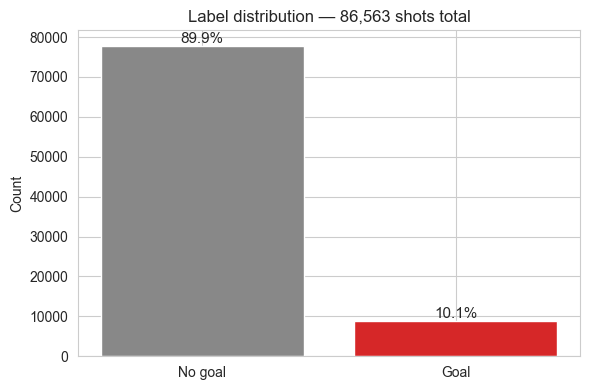

goal
No goal    77794
Goal        8769
Name: count, dtype: int64

Base rate (P[goal]): 0.1013


In [32]:
label_counts = shots['goal'].value_counts().rename({0: 'No goal', 1: 'Goal'})
label_pct    = shots['goal'].value_counts(normalize=True).rename({0: 'No goal', 1: 'Goal'})

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
bars = ax.bar(label_counts.index, label_counts.values,
              color=['#888', '#d62728'])
for b, pct in zip(bars, label_pct.values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f'{pct:.1%}', ha='center', va='bottom', fontsize=11)
ax.set_title(f'Label distribution — {len(shots):,} shots total')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(label_counts)
print()
print(f'Base rate (P[goal]): {shots["goal"].mean():.4f}')



## Shot location

The two primary features in any xG model are distance and angle. Most xG models only account for this because it's the most important.


### Shot density heatmap
Brighter colours means more proportion of shots taken.


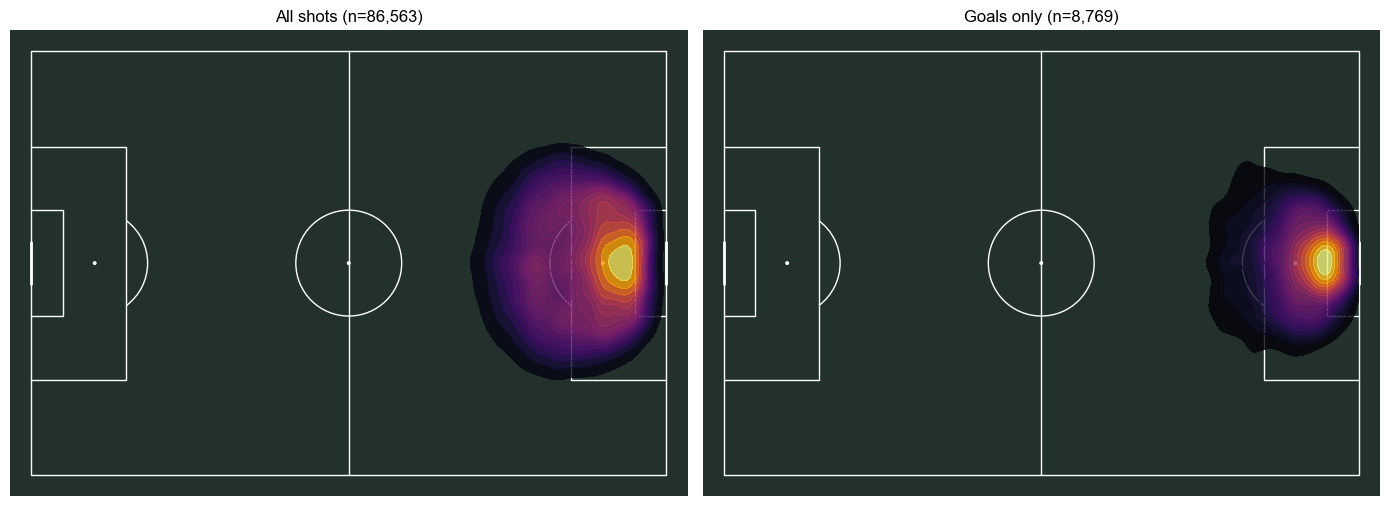

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, subset, title in [
    (axes[0], shots, f'All shots (n={len(shots):,})'),
    (axes[1], shots[shots['goal'] == 1], f'Goals only (n={shots["goal"].sum():,})'),
]:
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b',
                  line_color='white', linewidth=1)
    pitch.draw(ax=ax)
    pitch.kdeplot(subset['shot_x'], subset['shot_y'], ax=ax,
                  fill=True, levels=20, cmap='inferno', alpha=0.8)
    ax.set_title(title, color='black')

plt.tight_layout()
plt.show()


**Observation.** Goals are heavily concentrated in the 6-yard box and penalty spot (close and central to the goal). The "all shots" map shows a much longer tail of attempts from outside the box that rarely convert. This is the signal distance and angle will pick up.


### Goal rate by distance
Places shots into 5 meter distance buckets and compute conversion rate per band. 

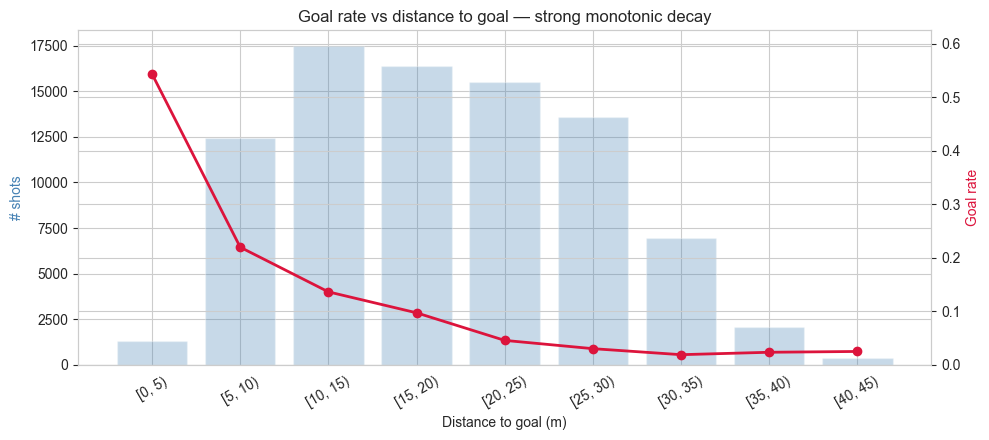

,n_shots,goal_rate
dist_bucket,,
"[0, 5)",1317,0.543660
"[5, 10)",12456,0.220055
"[10, 15)",17455,0.136637
"[15, 20)",16372,0.097484
"[20, 25)",15475,0.045945
"[25, 30)",13578,0.030490
"[30, 35)",6966,0.019236
"[35, 40)",2105,0.023753
"[40, 45)",396,0.025253


In [34]:
bins = np.arange(0, 50, 5)
shots['dist_bucket'] = pd.cut(shots['distance_to_goal'], bins=bins, right=False)

dist_agg = shots.groupby('dist_bucket', observed=True).agg(
    n_shots=('goal', 'size'),
    goal_rate=('goal', 'mean'),
)

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(range(len(dist_agg)), dist_agg['n_shots'], alpha=0.3, color='steelblue', label='# shots')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(range(len(dist_agg)))
ax1.set_xticklabels([str(b) for b in dist_agg.index], rotation=30)
ax1.set_xlabel('Distance to goal (m)')

ax2 = ax1.twinx()
ax2.plot(range(len(dist_agg)), dist_agg['goal_rate'], color='crimson',
         marker='o', linewidth=2, label='Goal rate')
ax2.set_ylabel('Goal rate', color='crimson')
ax2.set_ylim(0, max(dist_agg['goal_rate'].max() * 1.15, 0.5))

plt.title('Goal rate vs distance to goal — strong monotonic decay')
fig.tight_layout()
plt.show()

dist_agg


**Observation.** Conversion rate falls steeply with distance, from roughly 50–60% at point-blank range to under 5% beyond 25m. The relationship is
clearly non-linear (looks like exponential decay in this case), which means linear models will need engineered features (e.g. `1/distance`, log distance) or a non-linear model like XGBoost.

### Goal rate by angle
In this case, the angle means the angle (in degrees) subtended by the goal mouth from the shooter's position. A shot from directly in front of goal has a wide angle; a shot from the goal line on the wing has a near-zero angle.

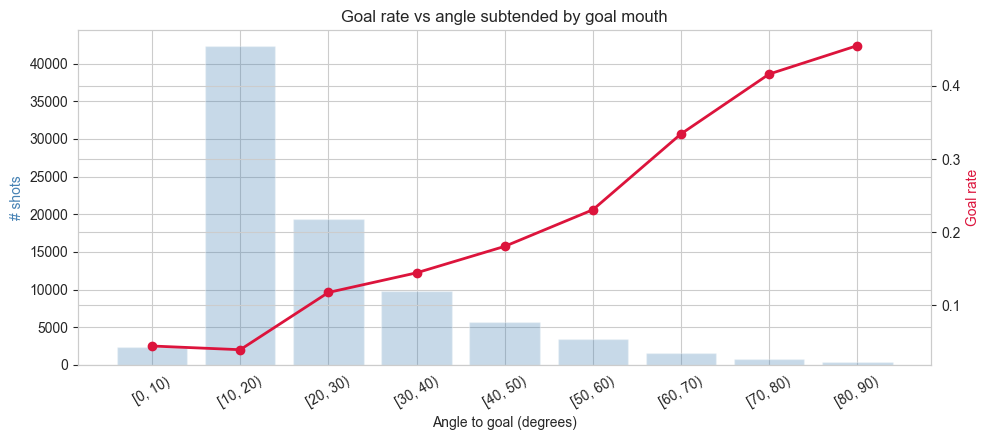

,n_shots,goal_rate
angle_bucket,,
"[0, 10)",2443,0.044617
"[10, 20)",42284,0.039566
"[20, 30)",19401,0.117777
"[30, 40)",9808,0.144576
"[40, 50)",5721,0.180738
"[50, 60)",3489,0.230725
"[60, 70)",1636,0.334352
"[70, 80)",781,0.416133
"[80, 90)",411,0.454988


In [35]:
angle_bins = np.arange(0, 91, 10)
shots['angle_bucket'] = pd.cut(shots['angle_to_goal'], bins=angle_bins, right=False)

angle_agg = shots.groupby('angle_bucket', observed=True).agg(
    n_shots=('goal', 'size'),
    goal_rate=('goal', 'mean'),
)

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(range(len(angle_agg)), angle_agg['n_shots'], alpha=0.3, color='steelblue')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(range(len(angle_agg)))
ax1.set_xticklabels([str(b) for b in angle_agg.index], rotation=30)
ax1.set_xlabel('Angle to goal (degrees)')

ax2 = ax1.twinx()
ax2.plot(range(len(angle_agg)), angle_agg['goal_rate'], color='crimson',
         marker='o', linewidth=2)
ax2.set_ylabel('Goal rate', color='crimson')

plt.title('Goal rate vs angle subtended by goal mouth')
fig.tight_layout()
plt.show()

angle_agg


**Observation.** Wider angles results in a higher conversion. This relationship is sort of linear. Angle and distance are correlated (close to goal = wide angle), so we'll need to see their correlation in a correlation matrix to decide whether both go in the model or not.


## Shot-context features
These will be categorical / boolean features that surround the geometric facts.

For each, we compare goal rates across categories. If a category meaningfully shifts conversion, we'll place it in the final model.


### Body part

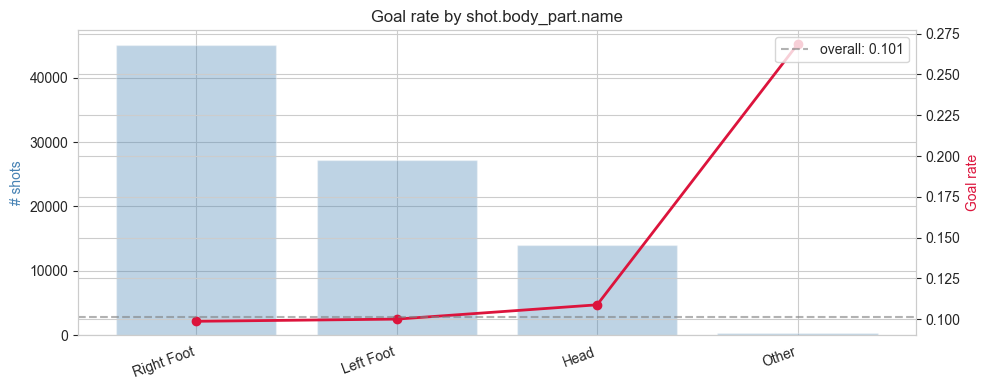

,n_shots,goal_rate
shot.body_part.name,,
Right Foot,45105,0.098747
Left Foot,27246,0.100088
Head,13955,0.108850
Other,257,0.268482


In [36]:
agg = shots.groupby('shot.body_part.name', observed=True).agg(
    n_shots=('goal', 'size'),
    goal_rate=('goal', 'mean'),
).sort_values('n_shots', ascending=False)
agg = agg[agg['n_shots'] >= 100]

fig, ax1 = plt.subplots(figsize=(10, 4))
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], alpha=0.35, color='steelblue')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs)
ax1.set_xticklabels(agg.index, rotation=20, ha='right')

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6,
            label=f'overall: {shots["goal"].mean():.3f}')
ax2.set_ylabel('Goal rate', color='crimson')
ax2.legend(loc='upper right')

plt.title('Goal rate by shot.body_part.name')
fig.tight_layout()
plt.show()

agg


**Observation.** Most shots are taken by the feet. Headers convert at a higher rate. The asymmetry between left and right foot is interesting and worth a one-hot too. Also "Other" has a remarkably high goal rate, but that might be due to it being very underrepresented in the data.


### Technique

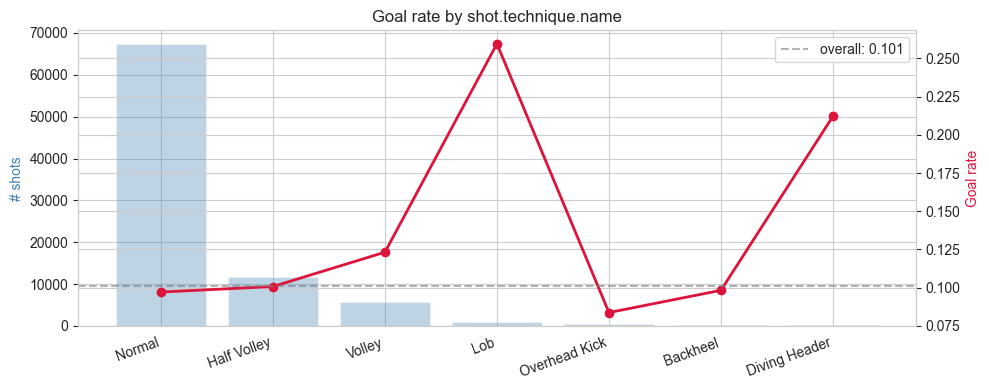

,n_shots,goal_rate
shot.technique.name,,
Normal,67228,0.097117
Half Volley,11705,0.100726
Volley,5633,0.123203
Lob,867,0.259516
Overhead Kick,454,0.083700
Backheel,346,0.098266
Diving Header,330,0.212121


In [37]:
agg = shots.groupby('shot.technique.name', observed=True).agg(
    n_shots=('goal', 'size'),
    goal_rate=('goal', 'mean'),
).sort_values('n_shots', ascending=False)
agg = agg[agg['n_shots'] >= 100]

fig, ax1 = plt.subplots(figsize=(10, 4))
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], alpha=0.35, color='steelblue')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs)
ax1.set_xticklabels(agg.index, rotation=20, ha='right')

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6,
            label=f'overall: {shots["goal"].mean():.3f}')
ax2.set_ylabel('Goal rate', color='crimson')
ax2.legend(loc='upper right')

plt.title('Goal rate by shot.technique.name')
fig.tight_layout()
plt.show()

agg


**Observation.** Every type of shot has a very different conversion rate. Will be useful to OHE as a categorical feature.


### Situation (play pattern)

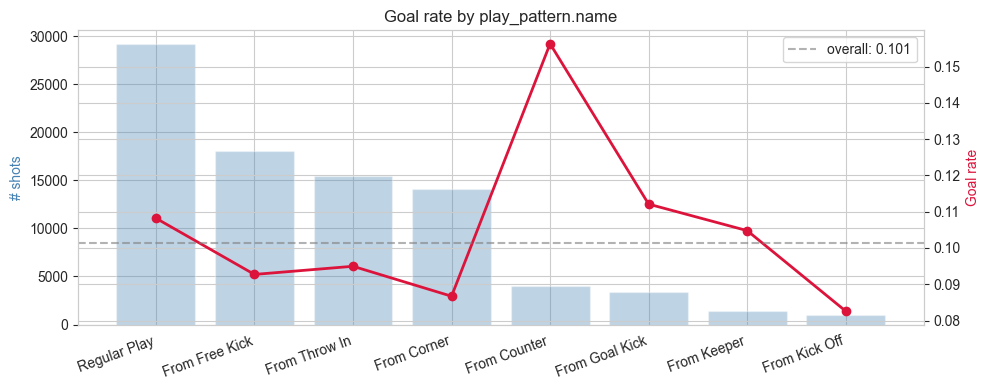

,n_shots,goal_rate
play_pattern.name,,
Regular Play,29141,0.108198
From Free Kick,18004,0.092702
From Throw In,15482,0.094949
From Corner,14072,0.086697
From Counter,3974,0.156266
From Goal Kick,3337,0.112077
From Keeper,1384,0.104769
From Kick Off,1005,0.082587


In [38]:
agg = shots.groupby('play_pattern.name', observed=True).agg(
    n_shots=('goal', 'size'),
    goal_rate=('goal', 'mean'),
).sort_values('n_shots', ascending=False)
agg = agg[agg['n_shots'] >= 200]

fig, ax1 = plt.subplots(figsize=(10, 4))
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], alpha=0.35, color='steelblue')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs)
ax1.set_xticklabels(agg.index, rotation=20, ha='right')

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6,
            label=f'overall: {shots["goal"].mean():.3f}')
ax2.set_ylabel('Goal rate', color='crimson')
ax2.legend(loc='upper right')

plt.title('Goal rate by play_pattern.name')
fig.tight_layout()
plt.show()

agg


**Observation.** Play patterns tell us the *origin* of the attack: open play, regain, corner, free kick, throw-in, etc. Set pieces have markedly different conversion rates (for instance, Counter attacks are a lot more effective than corners).


### Shot type

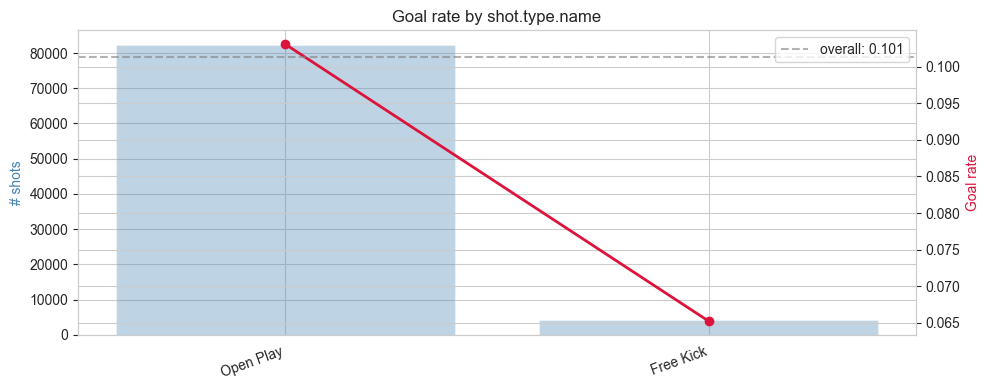

,n_shots,goal_rate
shot.type.name,,
Open Play,82304,0.103069
Free Kick,4230,0.065248


In [39]:
agg = shots.groupby('shot.type.name', observed=True).agg(
    n_shots=('goal', 'size'),
    goal_rate=('goal', 'mean'),
).sort_values('n_shots', ascending=False)
agg = agg[agg['n_shots'] >= 50]

fig, ax1 = plt.subplots(figsize=(10, 4))
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], alpha=0.35, color='steelblue')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs)
ax1.set_xticklabels(agg.index, rotation=20, ha='right')

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6,
            label=f'overall: {shots["goal"].mean():.3f}')
ax2.set_ylabel('Goal rate', color='crimson')
ax2.legend(loc='upper right')

plt.title('Goal rate by shot.type.name')
fig.tight_layout()
plt.show()

agg


**Observation.** `shot.type` usually also includes Penalties, however we've decided to exclude them from the model. From our prior EDA, we found out that penalties had about a 75% conversion rate, and each penalty is the exact same in a spatial sense. So considering it wouldn't be very useful/informative.

However, we do see that Free Kicks have a much lower conversion rate, which makes sense because it's always a shot from outside the box. Will be useful to consider, but maybe the distance to goal will account for most of the variance.

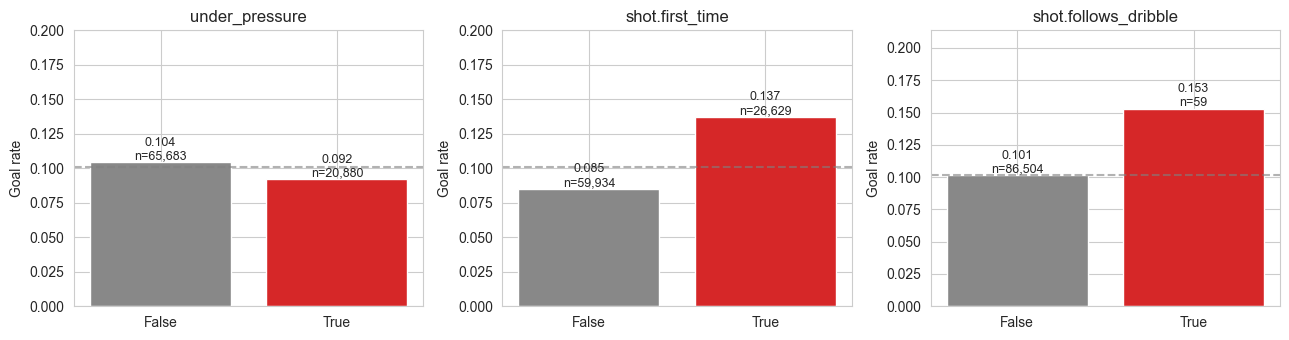

In [40]:
bool_feats = ['under_pressure', 'shot.first_time', 'shot.follows_dribble']
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
overall = shots['goal'].mean()

for ax, feat in zip(axes, bool_feats):
    grp = shots.groupby(feat)['goal'].agg(['size', 'mean'])
    ax.bar(['False', 'True'], grp['mean'].values, color=['#888', '#d62728'])
    ax.axhline(overall, color='gray', linestyle='--', alpha=0.6)
    for i, (n, r) in enumerate(zip(grp['size'].values, grp['mean'].values)):
        ax.text(i, r, f'{r:.3f}\nn={n:,}', ha='center', va='bottom', fontsize=9)
    ax.set_title(feat)
    ax.set_ylim(0, max(grp['mean'].max() * 1.4, 0.2))
    ax.set_ylabel('Goal rate')

plt.tight_layout()
plt.show()


**Observations on the boolean features:**

- **`under_pressure`** : shots taken under defender pressure convert *less* than unpressured shots, as expected. Modest but consistent gap.
- **`shot.first_time`** : first-time shots tend to convert *higher* than controlled shots in our data; this is partly because first-time finishes happen on cutbacks and tap-ins (location confound).
- **`shot.follows_dribble`** : small sample but a real lift; dribbling past a defender opens the angle.

Will be useful to consider these three features.

## Goalkeeper features

This is the section that distinguishes our project from a standard xG model. We extracted the opposition goalkeeper's location from each shot's freeze frame.

The thesis we want to test:

> *Holding shot geometry constant, goalkeeper position carries additional predictive signal that public xG models throw away.*


### Where do keepers stand at the moment of a shot?

Shown through a heatmap of GK location on the pitch. The goal is at x=120.


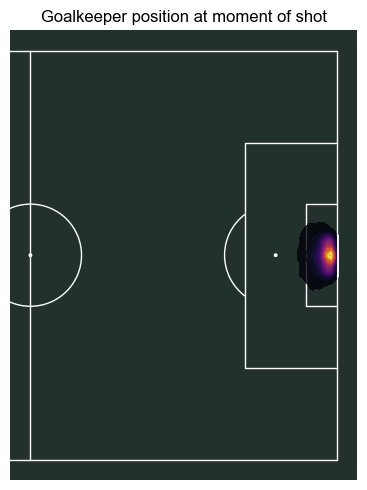

In [41]:
gk_df = shots[shots['gk_location'].notna()].copy()

fig, ax = plt.subplots(figsize=(9, 5))
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b',
              line_color='white', linewidth=1, half=True)
pitch.draw(ax=ax)
pitch.kdeplot(gk_df['gk_x'], gk_df['gk_y'], ax=ax,
              fill=True, levels=20, cmap='inferno', alpha=0.8)
ax.set_title('Goalkeeper position at moment of shot', color='black')
plt.tight_layout()
plt.show()


**Observation.** The mode sits just in front of the goal line, biased slightly toward the central penalty spot. But keepers do come off the line, and they shade toward where the ball is. This means there IS variation in GK position to exploit. Useful feature!

### GK distance from goal line vs goal rate

We define *off-line* distance as `120 - gk_x`. Hypothesis: keepers who are off their line concede more goals (because the shooter can chip or beat them on either side).

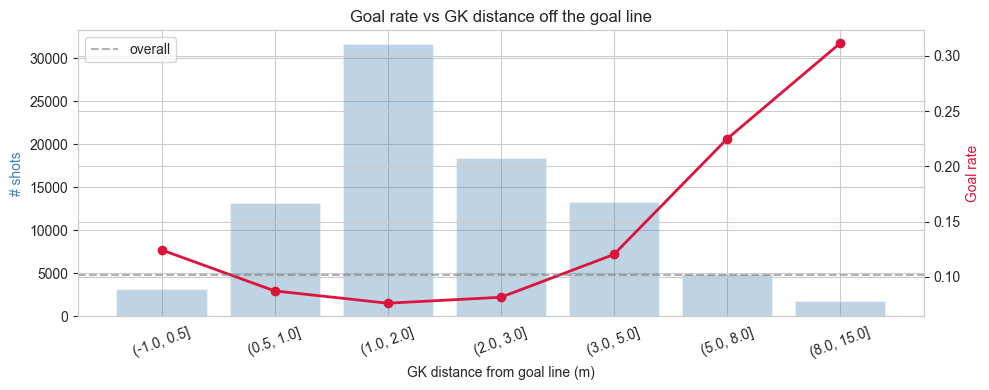

,n_shots,goal_rate
off_line_bucket,,
"(-1.0, 0.5]",3146,0.124285
"(0.5, 1.0]",13175,0.087211
"(1.0, 2.0]",31631,0.076096
"(2.0, 3.0]",18352,0.081463
"(3.0, 5.0]",13310,0.120210
"(5.0, 8.0]",4868,0.224733
"(8.0, 15.0]",1812,0.311258


In [42]:
bins = [-1, 0.5, 1, 2, 3, 5, 8, 15]
gk_df['off_line_bucket'] = pd.cut(gk_df['gk_distance_to_goal_line'], bins=bins)
agg = gk_df.groupby('off_line_bucket', observed=True).agg(
    n_shots=('goal', 'size'), goal_rate=('goal', 'mean'))

fig, ax1 = plt.subplots(figsize=(10, 4))
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], alpha=0.35, color='steelblue')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs); ax1.set_xticklabels([str(b) for b in agg.index], rotation=20)
ax1.set_xlabel('GK distance from goal line (m)')

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6,
            label='overall')
ax2.set_ylabel('Goal rate', color='crimson'); ax2.legend()
plt.title('Goal rate vs GK distance off the goal line')
plt.tight_layout(); plt.show()

agg


**Observation**. We see a non-linear pattern here. Goal rate is minimized when keeper is around 1-3 meters from the goal line, but increases if they are any less or any more, sort of like a parabola. This will be a good indicator for our model.

### GK lateral offset vs goal rate

Distance from the central y=40 line. A keeper shading to one side leaves more
of the opposite side of the goal exposed.


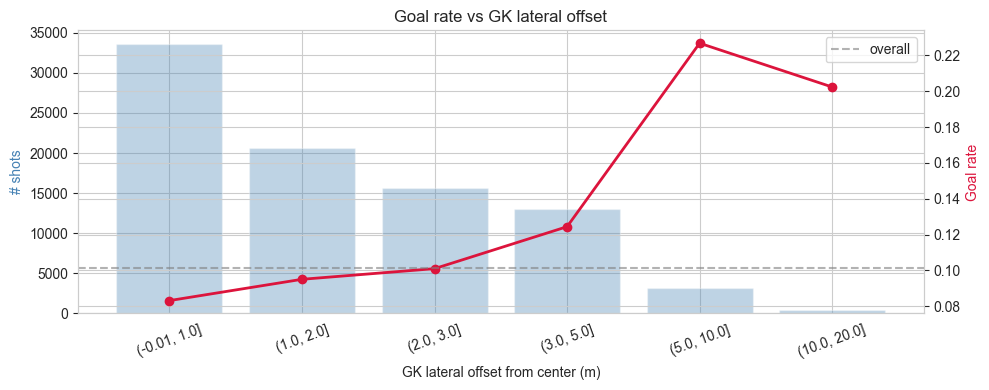

,n_shots,goal_rate
lat_bucket,,
"(-0.01, 1.0]",33622,0.083190
"(1.0, 2.0]",20637,0.095072
"(2.0, 3.0]",15661,0.101015
"(3.0, 5.0]",13035,0.124434
"(5.0, 10.0]",3161,0.226827
"(10.0, 20.0]",420,0.202381


In [43]:
bins = [-0.01, 1, 2, 3, 5, 10, 20]
gk_df['lat_bucket'] = pd.cut(gk_df['gk_lateral_offset'], bins=bins)
agg = gk_df.groupby('lat_bucket', observed=True).agg(
    n_shots=('goal', 'size'), goal_rate=('goal', 'mean'))

fig, ax1 = plt.subplots(figsize=(10, 4))
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], alpha=0.35, color='steelblue')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs); ax1.set_xticklabels([str(b) for b in agg.index], rotation=20)
ax1.set_xlabel('GK lateral offset from center (m)')

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6, label='overall')
ax2.set_ylabel('Goal rate', color='crimson'); ax2.legend()
plt.title('Goal rate vs GK lateral offset')
plt.tight_layout(); plt.show()
agg


**Observation**. As expected, a keeper with a higher lateral offset is usually conceding more goals. Lowest goal conversion happens when the keeper is nearest to the center of the goal.

### GK distance to shooter vs goal rate

How close the keeper is to the shooter? Basically a proxy for "the keeper has closed down the angle". Smaller distance should correlate with lower conversion.

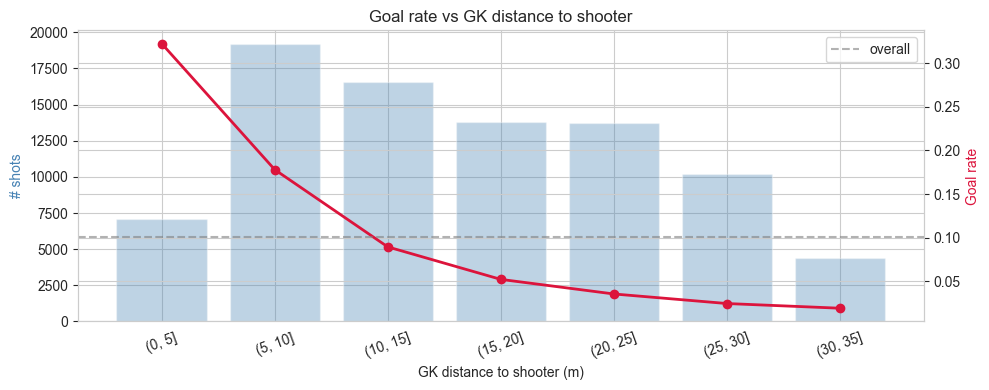

,n_shots,goal_rate
gk2shot_bucket,,
"(0, 5]",7098,0.322626
"(5, 10]",19174,0.178054
"(10, 15]",16592,0.089441
"(15, 20]",13759,0.052184
"(20, 25]",13734,0.035459
"(25, 30]",10165,0.024496
"(30, 35]",4393,0.019121


In [44]:
bins = np.arange(0, 40, 5)
gk_df['gk2shot_bucket'] = pd.cut(gk_df['gk_distance_to_shot'], bins=bins)
agg = gk_df.groupby('gk2shot_bucket', observed=True).agg(
    n_shots=('goal', 'size'), goal_rate=('goal', 'mean'))

fig, ax1 = plt.subplots(figsize=(10, 4))
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], alpha=0.35, color='steelblue')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs); ax1.set_xticklabels([str(b) for b in agg.index], rotation=20)
ax1.set_xlabel('GK distance to shooter (m)')

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6, label='overall')
ax2.set_ylabel('Goal rate', color='crimson'); ax2.legend()
plt.title('Goal rate vs GK distance to shooter')
plt.tight_layout(); plt.show()
agg


**Observation** Very smooth non-linear relationship that can be exploited through a decision tree model like xGBoost.

However.


**Possible confounding with distance-to-goal.** `gk_distance_to_shot` is strongly correlated with `distance_to_goal` (closer shots → closer GK).
So an unconditioned bar chart can be misleading. We will have to see the correlation matrix and ablation study to see how `gk_distance_to_shot` behaves in the model.


### The "two identical shots, different keeper" comparison

Pick a tight slice of distance + angle, then look at how goal rate varies with GK off-line distance *within that slice*. If GK position matters independently of geometry, we should see goal rate move.


Slice size: 16,477 shots, overall goal rate 0.141
                 n        gr
off                         
(-0.01, 0.5]   518  0.081081
(0.5, 1.5]    5469  0.076431
(1.5, 3.0]    5929  0.109462
(3.0, 6.0]    3050  0.225574
(6.0, 15.0]   1490  0.339597


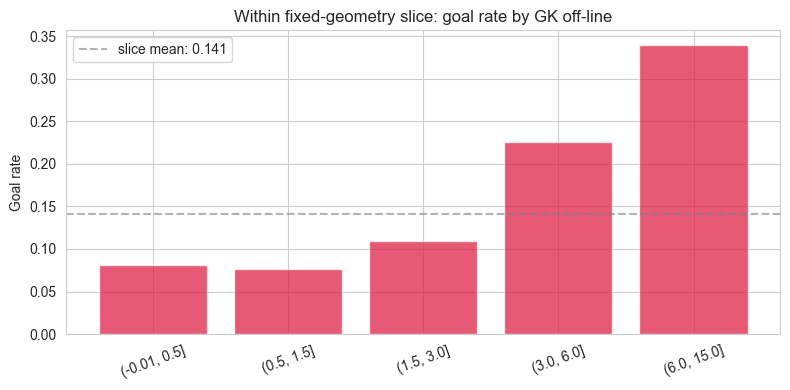

In [45]:
slice_mask = (
    (gk_df['distance_to_goal'].between(10, 16))
    & (gk_df['angle_to_goal'].between(20, 40))
    & (gk_df['shot.type.name'] == 'Open Play')
)
slc = gk_df[slice_mask]
print(f'Slice size: {len(slc):,} shots, overall goal rate {slc["goal"].mean():.3f}')

bins = [-0.01, 0.5, 1.5, 3, 6, 15]
slc = slc.assign(off=pd.cut(slc['gk_distance_to_goal_line'], bins=bins))
agg = slc.groupby('off', observed=True).agg(n=('goal','size'), gr=('goal','mean'))
print(agg)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(agg)), agg['gr'], color='crimson', alpha=0.7)
ax.set_xticks(range(len(agg))); ax.set_xticklabels([str(b) for b in agg.index], rotation=20)
ax.axhline(slc['goal'].mean(), color='gray', linestyle='--', alpha=0.6,
           label=f'slice mean: {slc["goal"].mean():.3f}')
ax.set_ylabel('Goal rate'); ax.set_title('Within fixed-geometry slice: goal rate by GK off-line')
ax.legend()
plt.tight_layout(); plt.show()


As the bars are significantly different, the GK feature carries information **beyond** distance and angle.

## Available goal angle 

The **available goal angle** is an engineered feature using the positions of the defenders and goalkeeper. From the shooter's vantage point, we compute the angular range of the goal mouth that is *not blocked* by either the goalkeeper or any opposition outfield defender between the shooter and the goal. Computed as:

```
available_goal_angle = angle_to_goal − union(GK blocked, defender blocked)
available_goal_fraction = available_goal_angle / angle_to_goal
```

`available_goal_fraction` ∈ [0, 1] is the cleaner reportable version, thus distance-normalized.


### Distribution of `available_goal_fraction`

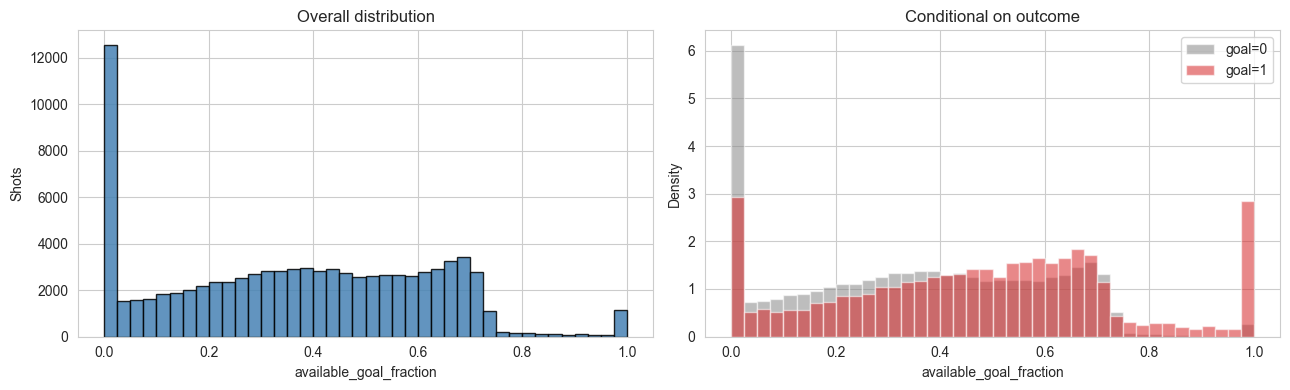

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(shots['available_goal_fraction'], bins=40, color='steelblue',
             edgecolor='black', alpha=0.85)
axes[0].set_xlabel('available_goal_fraction')
axes[0].set_ylabel('Shots')
axes[0].set_title('Overall distribution')

for label, color in [(0, '#888'), (1, '#d62728')]:
    sub = shots[shots['goal'] == label]['available_goal_fraction']
    axes[1].hist(sub, bins=40, density=True, alpha=0.55,
                 label=f'goal={label}', color=color)
axes[1].set_xlabel('available_goal_fraction')
axes[1].set_ylabel('Density')
axes[1].set_title('Conditional on outcome')
axes[1].legend()

plt.tight_layout(); plt.show()


**Observation.** Most shots happen with the goal mostly blocked (left peak near 0). Goals are noticeably overrepresented in the right tail (0.6–1.0): exactly what we'd want from a predictive feature. We can see that the density of goal increases relative to the density of no goals as available goal fraction increases.


### Goal rate by `available_goal_fraction`

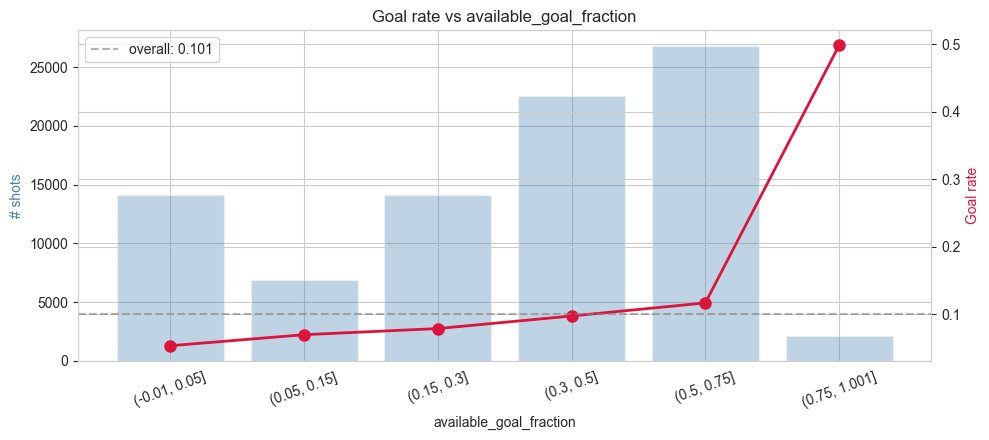

,n_shots,goal_rate
avail_bucket,,
"(-0.01, 0.05]",14088,0.053734
"(0.05, 0.15]",6908,0.070064
"(0.15, 0.3]",14073,0.079159
"(0.3, 0.5]",22564,0.097766
"(0.5, 0.75]",26781,0.117135
"(0.75, 1.001]",2149,0.498371


In [47]:
bins = [-0.01, 0.05, 0.15, 0.30, 0.50, 0.75, 1.001]
shots['avail_bucket'] = pd.cut(shots['available_goal_fraction'], bins=bins)
agg = shots.groupby('avail_bucket', observed=True).agg(
    n_shots=('goal', 'size'),
    goal_rate=('goal', 'mean'),
)

fig, ax1 = plt.subplots(figsize=(10, 4.5))
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], alpha=0.35, color='steelblue', label='# shots')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs); ax1.set_xticklabels([str(b) for b in agg.index], rotation=20)
ax1.set_xlabel('available_goal_fraction')

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2, ms=8)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6,
            label=f'overall: {shots["goal"].mean():.3f}')
ax2.set_ylabel('Goal rate', color='crimson')
ax2.legend(loc='upper left')

plt.title('Goal rate vs available_goal_fraction')
plt.tight_layout(); plt.show()

agg


This gives a better idea of how available goal fraction relates to goal rate. Goal rate climbs from
~6% when the goal is fully blocked to over 50% when it's wide open. The relationship is monotonic, steep, and clearly real.

### Decorrelation from raw distance

A concern: maybe `available_goal_fraction` is just a proxy for distance: close shots have larger angles, so naturally more "available" goal. The scatter below tests this directly. If the feature were a pure distance proxy, goal-vs-no-goal would split by distance alone, not by fraction.


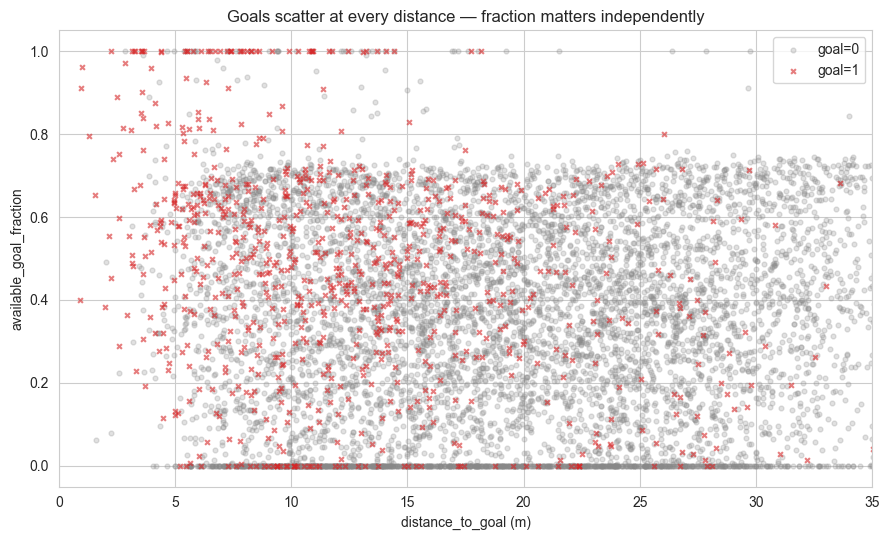

Correlation distance_to_goal × available_goal_fraction: 0.002


In [48]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sub = shots.sample(min(8000, len(shots)), random_state=42)  # subsample for plot speed
for lbl, color, marker, alpha in [(0, '#888', 'o', 0.25), (1, '#d62728', 'x', 0.6)]:
    s = sub[sub['goal'] == lbl]
    ax.scatter(s['distance_to_goal'], s['available_goal_fraction'],
               s=12, alpha=alpha, color=color, marker=marker, label=f'goal={lbl}')

ax.set_xlabel('distance_to_goal (m)')
ax.set_ylabel('available_goal_fraction')
ax.set_title('Goals scatter at every distance — fraction matters independently')
ax.set_xlim(0, 35); ax.legend()
plt.tight_layout(); plt.show()

print(f'Correlation distance_to_goal × available_goal_fraction: '
      f'{shots[["distance_to_goal","available_goal_fraction"]].corr().iloc[0,1]:.3f}')


**Observation.** Even after accounting for distance, goals cluster toward high `available_goal_fraction` values. The two features are not too correlated.


## Deriving other freeze-frame features

Beyond the integrated `available_goal_angle`, the freeze frame yields several simpler aggregates. They are probably individually less predictive but XGBoost should combine them productively through interactions with geometry.

### Defenders in the shot cone

How many opposition outfield players sit inside the triangle (shooter, left post, right post)? Each one is an potential obstruction directly between the shooter and the goal.


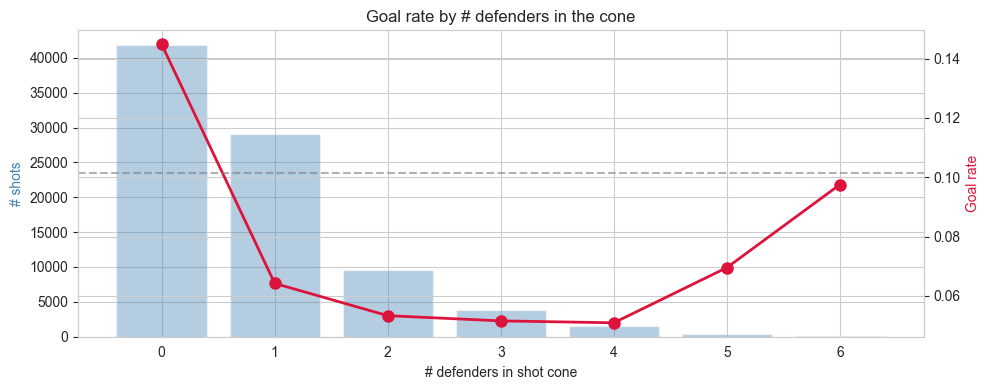

,n_shots,goal_rate
defenders_in_cone,,
0,41836,0.144804
1,29109,0.064241
2,9633,0.053358
3,3856,0.051608
4,1511,0.050960
5,460,0.069565
6,123,0.097561


In [49]:
agg = (shots.groupby('defenders_in_cone').agg(n_shots=('goal','size'), goal_rate=('goal','mean')))
agg = agg[agg['n_shots'] >= 100]

fig, ax1 = plt.subplots(figsize=(10, 4))
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], color='steelblue', alpha=0.4)
ax1.set_xlabel('# defenders in shot cone')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs); ax1.set_xticklabels(agg.index)

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2, ms=8)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6)
ax2.set_ylabel('Goal rate', color='crimson')

plt.title('Goal rate by # defenders in the cone')
plt.tight_layout(); plt.show()

agg


**Observation.** Clearly non-linear, sort of a parabolic shape. Zero defenders in the cone gives the highest conversion, each additional defender meaningfully cuts the goal rate. Above ~3 defenders sample sizes get small, but the goal rate covers to close to the baseline rate of 0.10.


### Distance to nearest defender

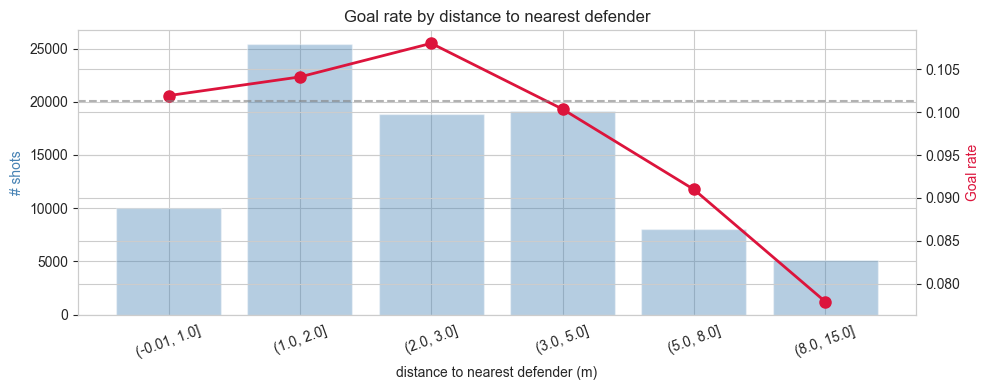

,n_shots,goal_rate
nd_bucket,,
"(-0.01, 1.0]",10008,0.101918
"(1.0, 2.0]",25429,0.104094
"(2.0, 3.0]",18805,0.108003
"(3.0, 5.0]",19115,0.100340
"(5.0, 8.0]",8045,0.090988
"(8.0, 15.0]",5094,0.077935


In [50]:
bins = [-0.01, 1, 2, 3, 5, 8, 15]
shots['nd_bucket'] = pd.cut(shots['distance_to_nearest_defender'], bins=bins)
agg = shots.groupby('nd_bucket', observed=True).agg(
    n_shots=('goal','size'), goal_rate=('goal','mean'))

fig, ax1 = plt.subplots(figsize=(10, 4))
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], color='steelblue', alpha=0.4)
ax1.set_xlabel('distance to nearest defender (m)')
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs); ax1.set_xticklabels([str(b) for b in agg.index], rotation=20)

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2, ms=8)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6)
ax2.set_ylabel('Goal rate', color='crimson')

plt.title('Goal rate by distance to nearest defender')
plt.tight_layout(); plt.show()

agg


**Observation:** Looks like the Goal Rate does depend on the distance to the nearest defender (low goal rates when defenders are very close or very far), but there might be possible confounding for the latter with `distance_to_goal` because long shots are taken when defenders are further away.

## Key pass features 

The key pass is the immediate pre-shot event (assist). We extract its origin location, length, angle, and StatsBomb's special-play tags (`cross`, `through_ball`, `cut_back`). About 72% of shots in our dataset
have a key pass; the rest are direct shots (regains, set-piece reboundings, deflections).


### Does having a key pass matter?

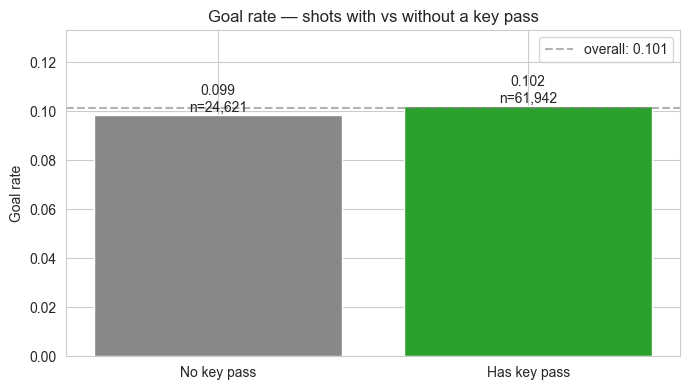

In [51]:
agg = shots.groupby('has_key_pass').agg(n_shots=('goal', 'size'), goal_rate=('goal', 'mean'))

fig, ax = plt.subplots(figsize=(7, 4))
labels = ['No key pass', 'Has key pass']
xs = range(len(agg))
ax.bar(xs, agg['goal_rate'].values, color=['#888','#2ca02c'])
for i, (n, gr) in enumerate(zip(agg['n_shots'].values, agg['goal_rate'].values)):
    ax.text(i, gr, f'{gr:.3f}\nn={n:,}', ha='center', va='bottom', fontsize=10)
ax.set_xticks(xs); ax.set_xticklabels(labels)
ax.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6,
           label=f'overall: {shots["goal"].mean():.3f}')
ax.set_ylabel('Goal rate')
ax.set_title('Goal rate — shots with vs without a key pass')
ax.set_ylim(0, max(agg['goal_rate'])*1.3); ax.legend()
plt.tight_layout(); plt.show()


**Observation.** Very slight benefit, but not really. But there may be additional value in the key pass' properties.


### Where did the assist originate?

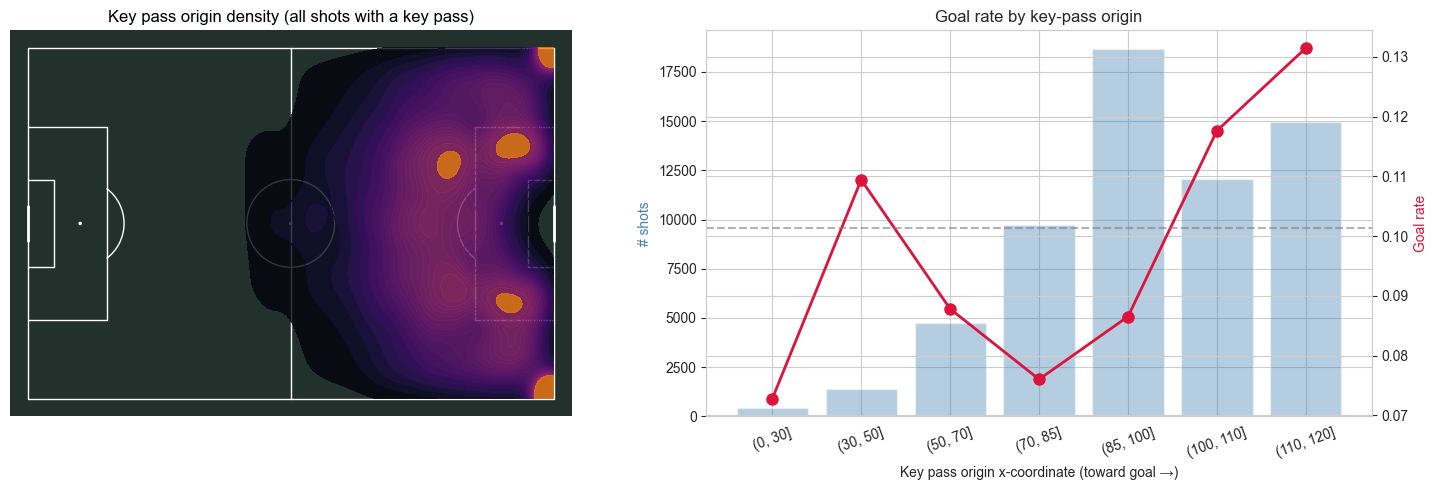

In [52]:
kp_df = shots[shots['has_key_pass'] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b',
              line_color='white', linewidth=1)
pitch.draw(ax=axes[0])
pitch.kdeplot(kp_df['kp_x'], kp_df['kp_y'], ax=axes[0],
              fill=True, levels=20, cmap='inferno', alpha=0.8)
axes[0].set_title('Key pass origin density (all shots with a key pass)', color='black')

bins = [0, 30, 50, 70, 85, 100, 110, 120]
kp_df['kp_x_bucket'] = pd.cut(kp_df['kp_x'], bins=bins)
agg = kp_df.groupby('kp_x_bucket', observed=True).agg(
    n_shots=('goal','size'), goal_rate=('goal','mean'))

ax1 = axes[1]
xs = range(len(agg))
ax1.bar(xs, agg['n_shots'], color='steelblue', alpha=0.4)
ax1.set_ylabel('# shots', color='steelblue')
ax1.set_xticks(xs); ax1.set_xticklabels([str(b) for b in agg.index], rotation=20)
ax1.set_xlabel('Key pass origin x-coordinate (toward goal →)')

ax2 = ax1.twinx()
ax2.plot(xs, agg['goal_rate'], color='crimson', marker='o', linewidth=2, ms=8)
ax2.axhline(shots['goal'].mean(), color='gray', linestyle='--', alpha=0.6)
ax2.set_ylabel('Goal rate', color='crimson')
ax2.set_title('Goal rate by key-pass origin')

plt.tight_layout(); plt.show()


**Observation.** The deeper into the attacking third the key pass originates (right side of the bar chart), the higher the conversion rate. There's also a peak at (30, 50], which might indicate a lob ball by the defender to initiate a counter attack. Thus, this variable has a lot of value


### Special-play types: cross, through ball, cutback

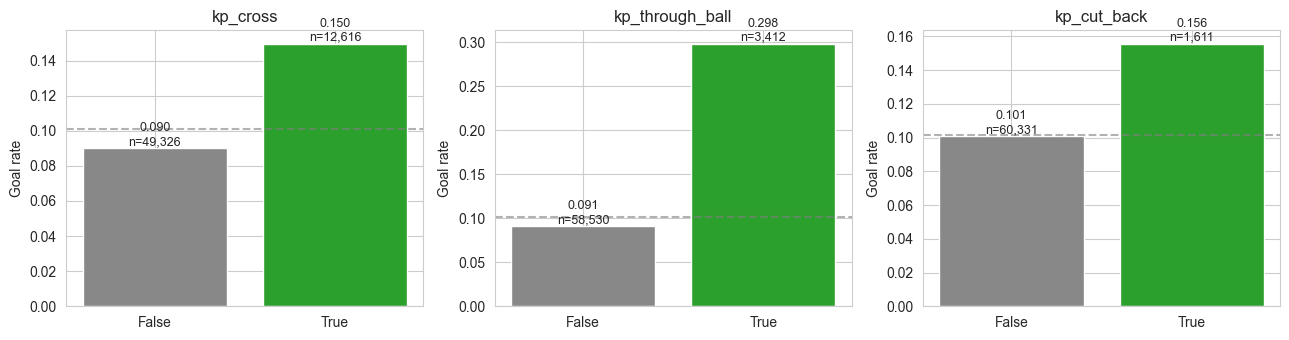

In [53]:
bool_feats = ['kp_cross', 'kp_through_ball', 'kp_cut_back']
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
overall = shots['goal'].mean()

for ax, feat in zip(axes, bool_feats):
    grp = kp_df.groupby(feat)['goal'].agg(['size', 'mean'])
    ax.bar(['False', 'True'], grp['mean'].values, color=['#888', '#2ca02c'])
    ax.axhline(overall, color='gray', linestyle='--', alpha=0.6)
    for i, (n, r) in enumerate(zip(grp['size'].values, grp['mean'].values)):
        ax.text(i, r, f'{r:.3f}\nn={n:,}', ha='center', va='bottom', fontsize=9)
    ax.set_title(feat)
    ax.set_ylabel('Goal rate')

plt.tight_layout(); plt.show()


**Observation.** There's a considerable difference in the conversion rates when these variables are True compared to when they are false. Especially through balls. We will need to include them in the model.

## Correlation analysis

Check which features overlap. Highly correlated pairs:
- Add no marginal info to tree models, but inflate logistic regression coefficients. Worth keeping in mind for regularization choice.
- Will show up redundantly in feature importance plots.


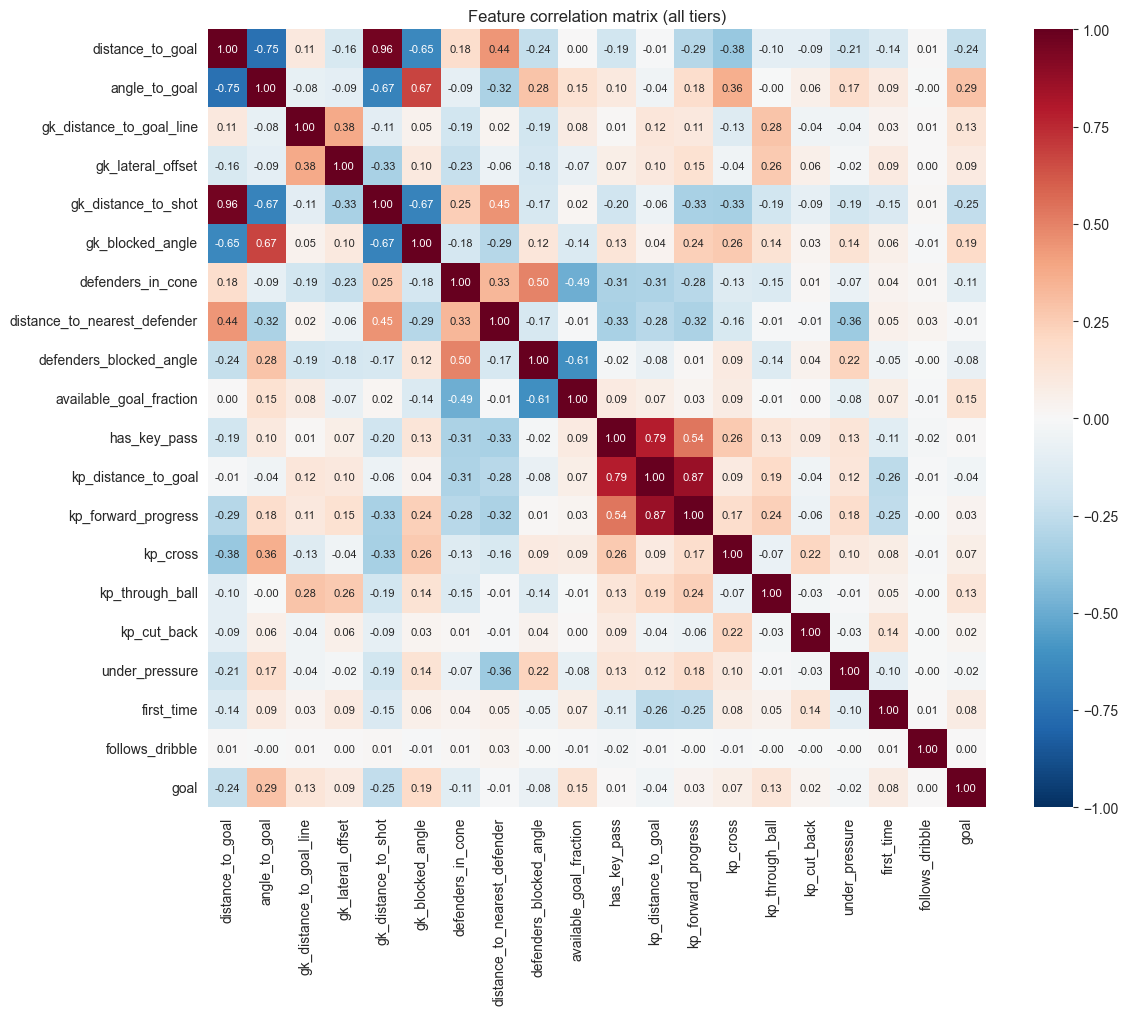

In [54]:
num_cols = [
    'distance_to_goal', 'angle_to_goal',
    'gk_distance_to_goal_line', 'gk_lateral_offset',
    'gk_distance_to_shot', 'gk_blocked_angle',
    'defenders_in_cone', 'distance_to_nearest_defender',
    'defenders_blocked_angle', 'available_goal_fraction',
    'has_key_pass', 'kp_distance_to_goal', 'kp_forward_progress',
    'kp_cross', 'kp_through_ball', 'kp_cut_back',
    'under_pressure', 'first_time', 'follows_dribble',
    'goal',
]
corr = shots[num_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            annot_kws={'size': 8})
ax.set_title('Feature correlation matrix (all tiers)')
plt.tight_layout(); plt.show()


We can read the last row (goal), to see what's most correlated with it and what we can consider for the final model.

- `angle_to_goal` and `gk_distance_to_shot` lead Tier 1
- `available_goal_fraction` and `shot_gk_angle` are competitive with the pure-geometry features: supporting the benefit of adding these variables to improve the model.
- Key-pass features have smaller marginal correlations but XGBoost can use them smartly through interactions with shot location and body part.

We need to consider some redunandcies:

- `gk_distance_to_goal` ≈ `gk_distance_to_goal_line` (when the GK is centered)
- `gk_blocked_angle` and `available_goal_fraction` both involve the GK: they capture overlapping info but are not identical (one is GK-only, the other includes outfield defenders)
- `kp_distance_to_goal` and `kp_x` carry overlapping signal
